# Copilot

In [1]:
from datetime import datetime

from bs4 import BeautifulSoup
import pandas as pd
import re
import numpy as np
from datetime import timedelta
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# Correct data

In [14]:
# df1 = pd.read_csv(f'data/autoscout/{datetime.now().strftime("%y.%m.%d")}_autoscout_raw.csv')
df1 = pd.read_csv(f'data/autoscout/24.04.04_autoscout_raw.csv')
df1['title'] = df1['brand'] + ' ' + df1['title']
df1 = df1.drop(['brand', 'rating'], axis=1)
df1['location'] = df1['location'].str.extract(r'ES-\d+\s(.*)', expand=False)
df1['year'] = df1['year'].str.split('/').str[1].astype(int)

# df2 = pd.read_csv(f'data/flexicar/{datetime.now().strftime("%y.%m.%d")}_flexicar_raw.csv')
df2 = pd.read_csv(f'data/flexicar/24.04.04_flexicar_raw.csv')
df2['location'] = df2['city']
df2['cv'] = df2['description'].str.extract(r'\((\d+)CV\)', expand=False)
df2['cv'] = df2['cv'].replace(np.nan, '0')
df2['cv'] = df2['cv'].astype(int)
df2['cv'] = df2['cv'].replace(0, np.nan)
df2 = df2.drop(['discounted_price', 'monthly_rate', 'iva_deducible', 'offer', 'city'], axis=1)

# df3 = pd.read_csv(f'data/ocasion/{datetime.now().strftime("%y.%m.%d")}_ocasion_raw.csv')
df3 = pd.read_csv(f'data/ocasion/24.04.04_ocasion_raw.csv')
df3['city'] = df3['city'].fillna('')
df3['district'] = df3['district'].fillna('')
df3['location'] = df3['city'] + ' ' + df3['district']
df3['location'] = df3['location'].replace(' ', np.nan)
df3 = df3.drop(['discounted_price', 'discount', 'status', 'city', 'district', 'libro', 'warranty', 'owner', 'vista'], axis=1)

In [15]:
df2 = df2[df1.columns]
df3 = df3[df1.columns]
df = pd.concat([df1,df2,df3], ignore_index=True)
df['location'] = df['location'].str.lower().str.strip()
df = df.drop_duplicates()
df = df.dropna(subset=['full_price'])
df['age'] = 2024 - df['year']
df = df.drop(['year'], axis=1)

df = df[df['full_price'] <= 15000]
df.drop_duplicates(subset=['title', 'description', 'full_price', 'mileage', 'transmission', 'fuel', 'cv', 'age'], inplace=True)


# Normalize and score

In [17]:
scaler = MinMaxScaler()
df_norm = df.copy()
df_norm['full_price'] = scaler.fit_transform(df_norm[['full_price']])
df_norm['age'] = scaler.fit_transform(df_norm[['age']])
df_norm['mileage'] = scaler.fit_transform(df_norm[['mileage']])
df_norm['cv'] = scaler.fit_transform(df_norm[['cv']])
df_norm['cv'] = df_norm['cv'].replace(np.nan, 0)

# Correct valence
df_norm['full_price'] = (df_norm['full_price'] - 1)* -1
df_norm['age'] = (df_norm['age'] - 1)* -1
df_norm['mileage'] = (df_norm['mileage'] - 1)* -1

df['rating'] = (df_norm.full_price * 2) + df_norm.cv + df_norm.mileage + df_norm.age
df['rating_no_cv'] = (df_norm.full_price * 2) + df_norm.mileage + df_norm.age
# df_norm.sort_values(by='rating', ascending=False)

df['description'] = df.title + ' ' + df.description
df['title'] = df['title'].apply(lambda x: x.split(" ")[0])

df.to_csv(f'data/{datetime.now().strftime("%y.%m.%d")}_assembled.csv', index=False)

In [18]:
df

,title,description,full_price,mileage,transmission,fuel,cv,location,url,age,rating,rating_no_cv
0,Citroen,Citroen Citroen C4 1.6 VTi Collection,6999.0,98840,Manual,Gasolina,120.0,madrid,https://www.autoscout24.es//anuncios/citroen-c...,10,2.563900,2.122723
1,Ford,Ford Ford C-Max 1.0 Ecoboost Auto-S&S Edition 125,7490.0,99000,Manual,Gasolina,125.0,tarragona,https://www.autoscout24.es//anuncios/ford-c-ma...,10,2.488583,1.998387
2,Peugeot,Peugeot Peugeot 308 5p 1.6 thp 16v Allure 156cv,7500.0,94000,Manual,Gasolina,156.0,cabo blanco,https://www.autoscout24.es//anuncios/peugeot-3...,11,2.728945,1.934828
3,Citroen,Citroen Citroen C4 1.6e-HDi S&S Collection 115,8000.0,94239,Manual,Diésel,114.0,mairena del aljarafe,https://www.autoscout24.es//anuncios/citroen-c...,11,2.189804,1.807451
4,Ford,Ford Ford C-Max 1.0 EcoBoost Start-Stopp-Syste...,8000.0,86000,Manual,Gasolina,125.0,madrid,https://www.autoscout24.es//anuncios/ford-c-ma...,11,2.380122,1.889926
...,...,...,...,...,...,...,...,...,...,...,...,...
6589,Toyota,Toyota Auris Hybrid Active (136 CV),13990.0,98982,Auto,Híbrido,136.0,barcelona palafolls,https://www.ocasionplus.com/coches-segunda-man...,9,1.082920,0.484881
6590,Hyundai,Hyundai i40 1.6 GDi Klass (135 CV),13900.0,92085,Manual,Gasolina,135.0,alicante denia,https://www.ocasionplus.com/coches-segunda-man...,9,1.164655,0.576419
6597,Peugeot,Peugeot 308 SW SW 1.2 PureTech Allure EAT6 (13...,14900.0,67929,Manual,Gasolina,130.0,valencia alzira,https://www.ocasionplus.com/coches-segunda-man...,9,1.107475,0.568260
6680,Citroën,Citroën C4 Aircross HDi 115 S&S 6v 2WD Seducti...,14900.0,44961,Manual,Diésel,114.0,barcelona terrassa av. st. eulalia,https://www.ocasionplus.com/coches-segunda-man...,9,1.180530,0.798177


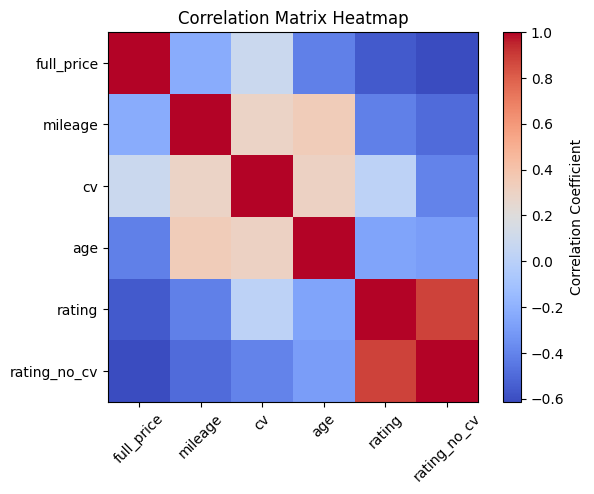

In [19]:
spearman_matrix = df.drop(['title', 'url', 'description', 'transmission', 'fuel', 'location'], axis=1).corr(method='spearman')
correlation_matrix = df.drop(['title', 'url', 'description', 'transmission', 'fuel', 'location'], axis=1).corr()

plt.imshow(correlation_matrix, cmap='coolwarm')  # Adjust 'coolwarm' for preferred colormap

# Add labels and title
plt.colorbar(label='Correlation Coefficient')
plt.xticks(range(len(spearman_matrix.columns)), spearman_matrix.columns, rotation=45)
plt.yticks(range(len(spearman_matrix.columns)), spearman_matrix.columns)
plt.title('Correlation Matrix Heatmap')

# Display the plot
plt.show()